# Machine Learning
Includes Support Vector Machine, Random Forest, Logistic Regression, Decision Tree, Naive Bayes.
These can be compared at evaluation metric

In [ ]:
import string
import matplotlib.pyplot as plt
import pandas as pd
import regex as re
import numpy as np
import seaborn as sns
import wordcloud
from wordcloud import WordCloud
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.preprocessing import LabelEncoder
from collections import Counter

## Data Understanding

In [3]:
data = pd.read_csv('D:\Projects\Emodet-App-New-Thesis\dataset\PRDECT-ID.csv')

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\ACER\AppData\Local\Temp\ipykernel_19800\3564021324.py:1: SyntaxWarning: invalid escape sequence '\P'
  data = pd.read_csv('D:\Projects\Emodet-App-New-Thesis\dataset\PRDECT-ID.csv')


In [4]:
kamus_tidak_baku = pd.read_csv('D:\Projects\Emodet-App-New-Thesis\dataset\kamusalay.csv', encoding='ISO-8859-1', header = None)
kamus_tb_dict = kamus_tidak_baku.set_index(0).to_dict('dict')[1]

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\ACER\AppData\Local\Temp\ipykernel_19800\4200447732.py:1: SyntaxWarning: invalid escape sequence '\P'
  kamus_tidak_baku = pd.read_csv('D:\Projects\Emodet-App-New-Thesis\dataset\kamusalay.csv', encoding='ISO-8859-1', header = None)


In [5]:
data.index +=1
display(data)
data.columns

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
1,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
2,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
3,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
5,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy
...,...,...,...,...,...,...,...,...,...,...,...
5396,Household,PCK-01 Penjepit Barang / Pickup Tool Ver.1 Ala...,Jakarta Pusat,35000,4.9,1431,562,5,"Harga bersaing, barang sesuai pesanan. Saya na...",Positive,Love
5397,Household,Ultrasonic Aroma Diffuser Humidifier Colorful ...,Jakarta Utara,99000,4.9,15529,4074,5,Beli ini krn Anak & Istri mau liburan di Jakar...,Positive,Love
5398,Household,Ultrasonic Aroma Diffuser Humidifier Colorful ...,Jakarta Utara,99000,4.9,15529,4074,5,"pengemasan barang baik, kondisi barang jg utuh...",Positive,Happy
5399,Household,Ultrasonic Aroma Diffuser Humidifier Colorful ...,Jakarta Utara,99000,4.9,15529,4074,5,Mungil tapi bekerja dng baik. Dan murahh terja...,Positive,Happy


Index(['Category', 'Product Name', 'Location', 'Price', 'Overall Rating',
       'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review',
       'Sentiment', 'Emotion'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 1 to 5400
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Category         5400 non-null   object 
 1   Product Name     5400 non-null   object 
 2   Location         5400 non-null   object 
 3   Price            5400 non-null   int64  
 4   Overall Rating   5400 non-null   float64
 5   Number Sold      5400 non-null   int64  
 6   Total Review     5400 non-null   int64  
 7   Customer Rating  5400 non-null   int64  
 8   Customer Review  5400 non-null   object 
 9   Sentiment        5400 non-null   object 
 10  Emotion          5400 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 464.2+ KB


In [7]:
data.describe()

,Price,Overall Rating,Number Sold,Total Review,Customer Rating
count,5.400000e+03,5400.000000,5400.000000,5400.000000,5400.000000
mean,2.386961e+05,4.854389,15961.951852,2168.645556,3.087037
std,8.016337e+05,0.108259,74201.913338,2915.666035,1.766258
min,1.000000e+02,4.100000,9.000000,4.000000,1.000000
25%,2.000000e+04,4.800000,1630.000000,576.000000,1.000000
50%,5.990000e+04,4.900000,3794.500000,1192.000000,3.000000
75%,1.500000e+05,4.900000,9707.000000,2582.000000,5.000000
max,1.539900e+07,5.000000,1000000.000000,24500.000000,5.000000


In [8]:
data['Customer Review']

1       Alhamdulillah berfungsi dengan baik. Packaging...
2       barang bagus dan respon cepat, harga bersaing ...
3       barang bagus, berfungsi dengan baik, seler ram...
4       bagus sesuai harapan penjual nya juga ramah. t...
5       Barang Bagus, pengemasan Aman, dapat Berfungsi...
                              ...                        
5396    Harga bersaing, barang sesuai pesanan. Saya na...
5397    Beli ini krn Anak & Istri mau liburan di Jakar...
5398    pengemasan barang baik, kondisi barang jg utuh...
5399    Mungil tapi bekerja dng baik. Dan murahh terja...
5400    Produk sesuai deskripsi, packing aman terlindu...
Name: Customer Review, Length: 5400, dtype: object

In [9]:
display(data['Customer Rating'].value_counts())
display(data['Emotion'].value_counts())

Customer Rating
5    2150
1    1832
2     561
3     462
4     395
Name: count, dtype: int64

Emotion
Happy      1770
Sadness    1202
Fear        920
Love        809
Anger       699
Name: count, dtype: int64

## Data Preparation

### Data Selecting

In [10]:
data = pd.DataFrame(data)
data = data[['Customer Review', 'Emotion']]
data = data.rename(columns={"Customer Review":"text", "Emotion":"label"})
data

,text,label
1,Alhamdulillah berfungsi dengan baik. Packaging...,Happy
2,"barang bagus dan respon cepat, harga bersaing ...",Happy
3,"barang bagus, berfungsi dengan baik, seler ram...",Happy
4,bagus sesuai harapan penjual nya juga ramah. t...,Happy
5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Happy
...,...,...
5396,"Harga bersaing, barang sesuai pesanan. Saya na...",Love
5397,Beli ini krn Anak & Istri mau liburan di Jakar...,Love
5398,"pengemasan barang baik, kondisi barang jg utuh...",Happy
5399,Mungil tapi bekerja dng baik. Dan murahh terja...,Happy


In [11]:
data['label']

1       Happy
2       Happy
3       Happy
4       Happy
5       Happy
        ...  
5396     Love
5397     Love
5398    Happy
5399    Happy
5400     Love
Name: label, Length: 5400, dtype: object

In [12]:
data.describe()

,text,label
count,5400,5400
unique,5305,5
top,jelek,Happy
freq,4,1770


### Data Cleaning

In [13]:
import regex as re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

def process_cleaning(text):

    # Replace emoji spesifik, numerik, url, non-word character by spacing
    text_cleaning_re = r"rt|url|[^\w\s]|'|nbsp|https\S+|[0-9]+"
    text_sub = re.sub(text_cleaning_re, ' ', str(text))

    # Remove strip / trims
    text_strip = text_sub.strip()

    # Remove punctutation / tanda baca
    translator = str.maketrans('', '', string.punctuation)
    text_no_punct = text_strip.translate(translator)

    # Lower Case
    text_lower = text_no_punct.casefold()

    # Tokenize
    text_token_stan = word_tokenize(text_lower)

    # Penggantian kata tidak baku / Normalization
    word_dict = []
    for word in text_token_stan:
        word_dict.append(kamus_tb_dict.get(word, word))
    tokens = " ".join(word_dict)

    # Tambah kata singkatan 
    more_stopword = ["sih","nya"]

    # menampung stopword ke variabel untuk jadi operator remove stopword
    stopword_user = StopWordRemoverFactory().get_stop_words() + more_stopword

    # Remove stopword
    token_new = word_tokenize(tokens)
    filter_new = []
    filter_new2 = [word.strip() for word in token_new]
    filter_new = [word for word in filter_new2 if not word in stopword_user]
    tokens = " ".join(filter_new)

    return tokens


In [14]:
import string

data['text_cleaned'] = data['text'].apply(process_cleaning)
x_cleaned = data['text_cleaned']
data.head(15)

,text,label,text_cleaned
1,Alhamdulillah berfungsi dengan baik. Packaging...,Happy,alhamdulillah berfungsi packaging aman respon ...
2,"barang bagus dan respon cepat, harga bersaing ...",Happy,barang bagus respon cepat harga bersaing
3,"barang bagus, berfungsi dengan baik, seler ram...",Happy,barang bagus berfungsi seler ramah pengiriman ...
4,bagus sesuai harapan penjual nya juga ramah. t...,Happy,bagus sesuai harapan penjual ramah terima kasi...
5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Happy,barang bagus pengemasan aman berfungsi
6,"barang bagus, seller ramah..",Happy,barang bagus seller ramah
7,mantap paten joss,Happy,mantap paten joss
8,"Works fine. Respon seller cepat, barang berfun...",Happy,works fine respon seller cepat barang berfungs...
9,barang bagus.. segel.. utuh.. original.. berfu...,Happy,barang bagus segel utuh original berfungsi sel...
10,Barang datang dan berfungsi dengan baik dan te...,Happy,barang berfungsi bagus lampu birunya


## Visualization

After Preprocessing


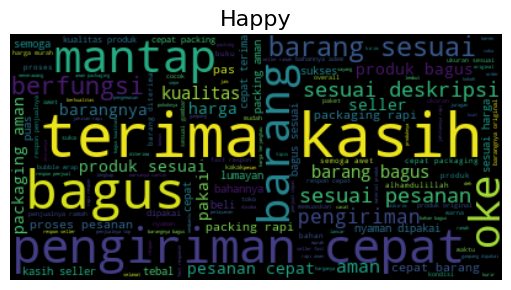

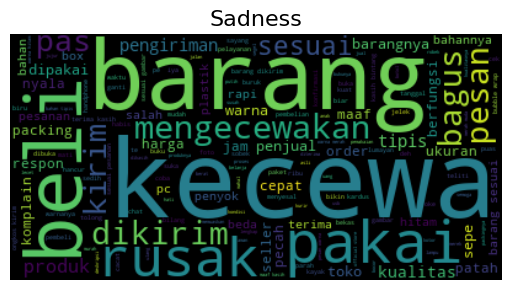

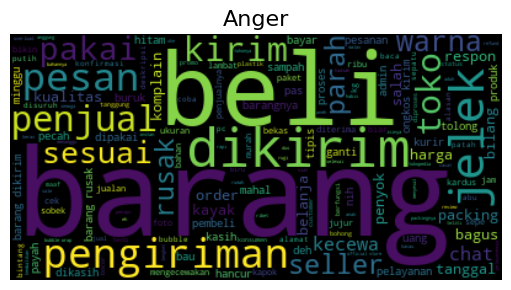

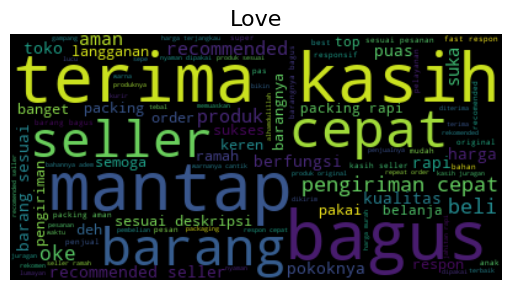

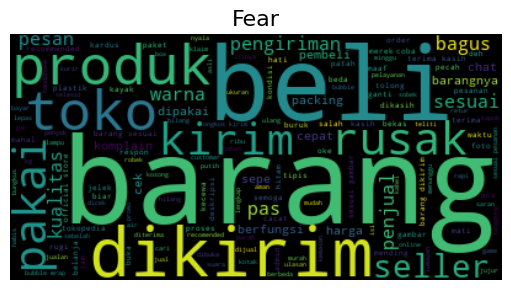

In [15]:
def process_wordCloud(value, emot):
    wordcloud = WordCloud(background_color = "black", max_words = 150).generate(value)
    fig = plt.figure(figsize = (5, 3))
    fig.set_layout_engine('constrained')
    plt.imshow(wordcloud, interpolation = "bilinear", alpha = 1)
    plt.title(emot, size=16)
    plt.axis("off")
    plt.show()
    print()
    return fig

# emotions = ['Happy', 'Love', 'Sadness', 'Fear', 'Anger']
emotions = data['label'].drop_duplicates()

print("After Preprocessing")
text_mixed_aft = ""
for emotion in emotions:
  input_emot = " ".join([emot for emot in data.loc[data['label'] == emotion, 'text']])
  CR_cleaned = process_cleaning(input_emot)
  process_wc = process_wordCloud(CR_cleaned, emotion)
  text_mixed_aft += CR_cleaned

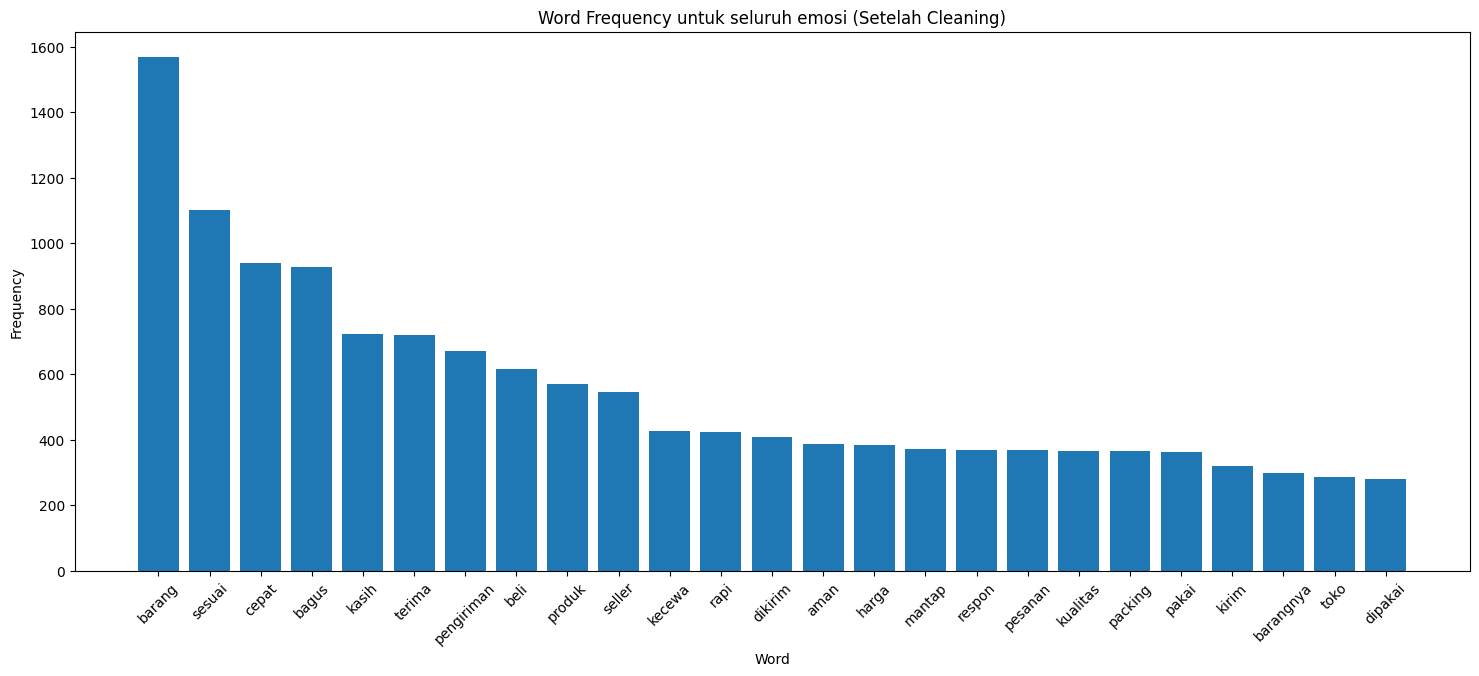

In [16]:
text_list = text_mixed_aft.split()

word_data = Counter(text_list).most_common(25)

plt.figure(figsize=(18, 7))
plt.bar(*zip(*word_data))
plt.title('Word Frequency untuk seluruh emosi (Setelah Cleaning)')
plt.xticks(rotation=45)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.show()

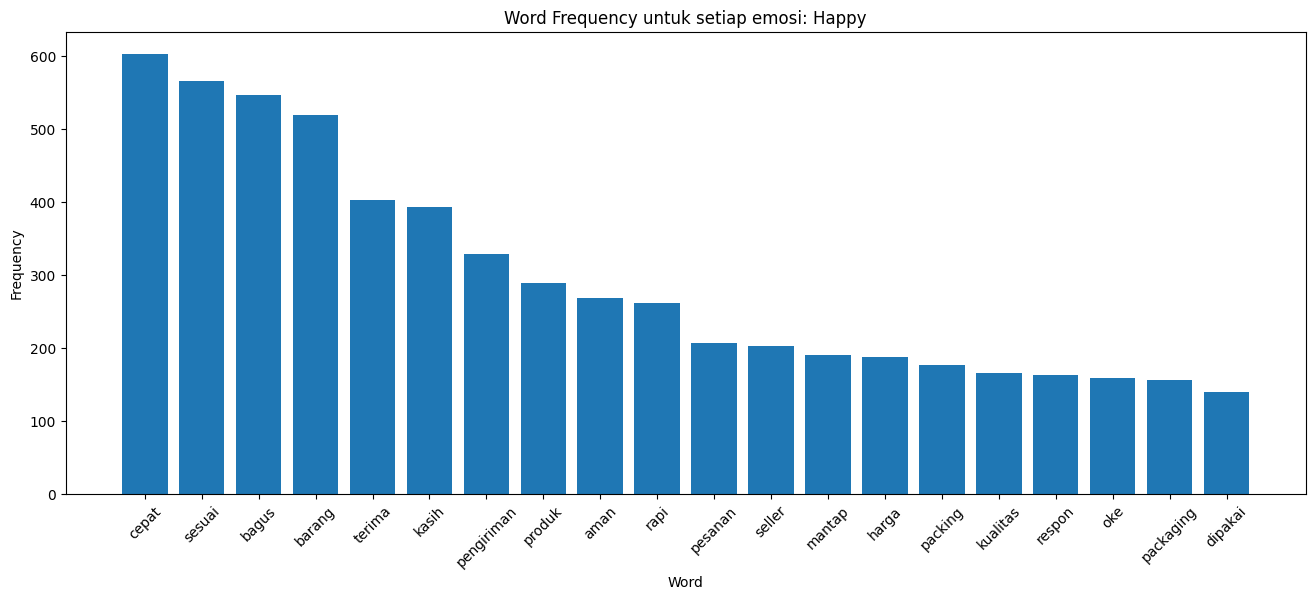

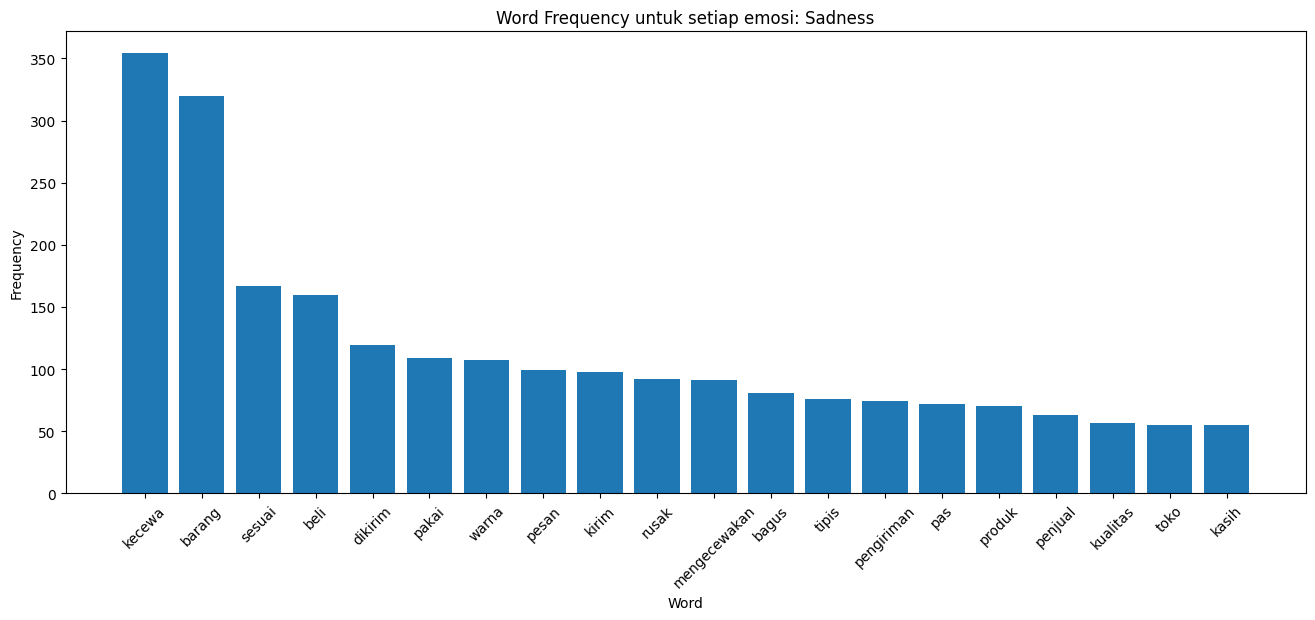

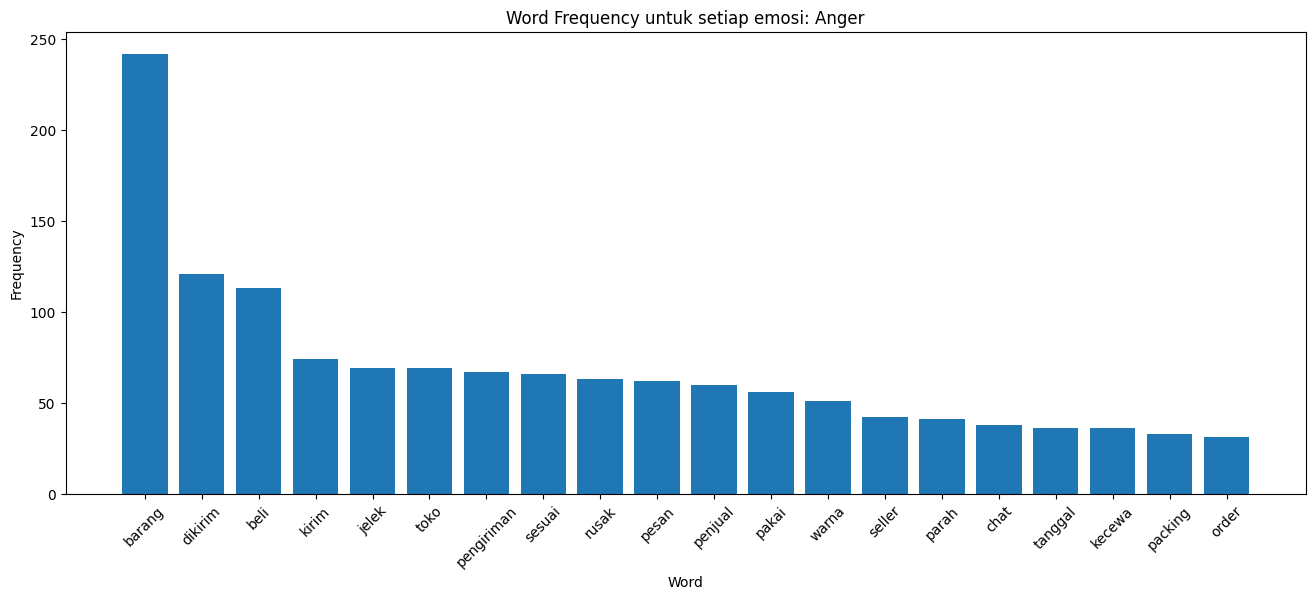

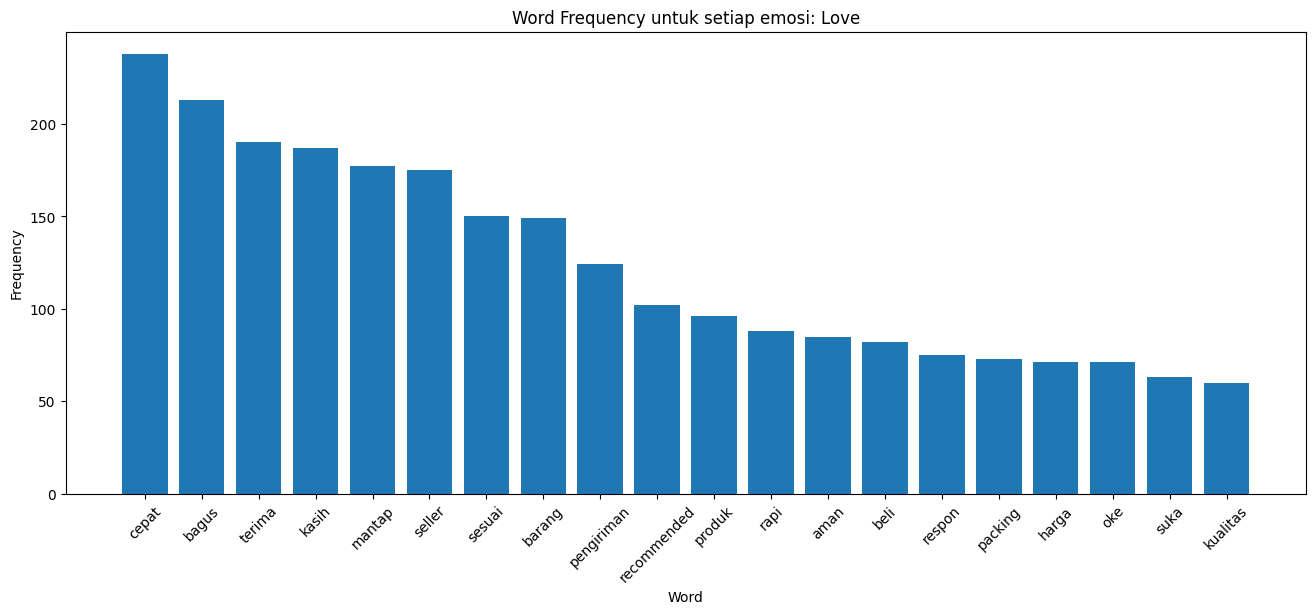

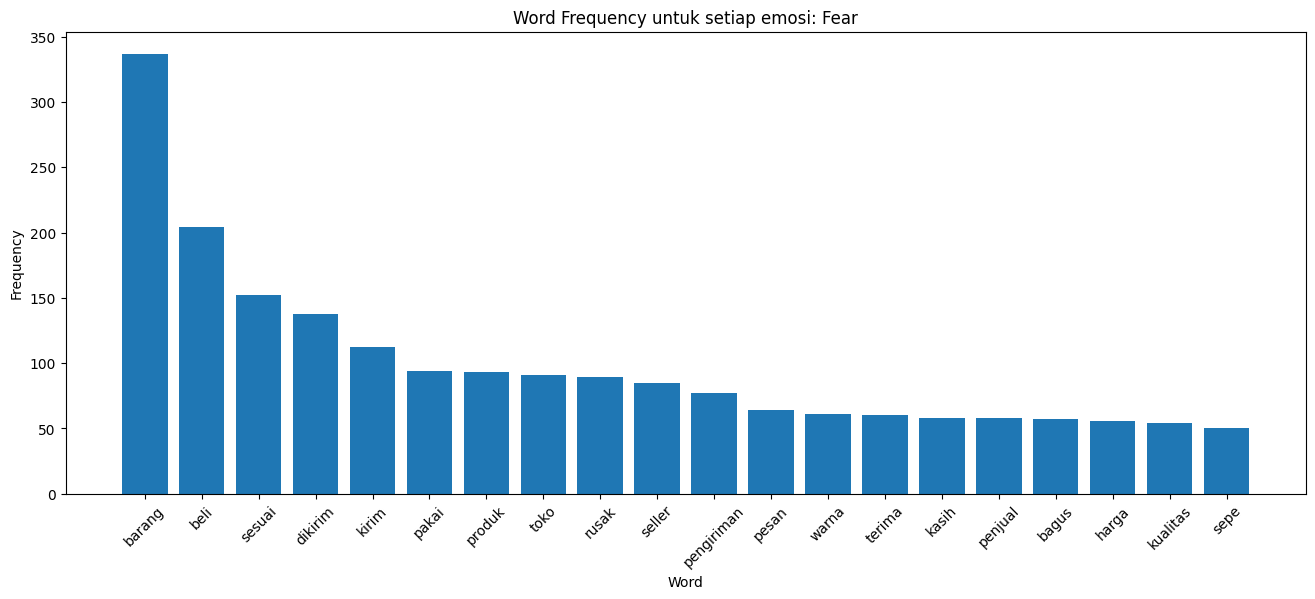

In [17]:
text_container = []
for emotion in emotions:
  text_container = " ".join([emot for emot in data.loc[data['label'] == emotion, 'text']])
  text_cleaned = process_cleaning(text_container)
  text_split = text_cleaned.split()
  word_data = Counter(text_split).most_common(20)

  plt.figure(figsize=(16, 6))
  plt.bar(*zip(*word_data))
  plt.title('Word Frequency untuk setiap emosi: ' + emotion)
  plt.xticks(rotation=45)
  plt.xlabel("Word")
  plt.ylabel("Frequency")
  plt.show()
  print()

## Data Construction

In [18]:
print(Counter(data['label']))
label_encoder = LabelEncoder()
data['label_replaced'] = label_encoder.fit_transform(data['label'])
print(Counter(data['label_replaced']))
y_replaced = data['label_replaced']
print(y_replaced)


Counter({'Happy': 1770, 'Sadness': 1202, 'Fear': 920, 'Love': 809, 'Anger': 699})
Counter({2: 1770, 4: 1202, 1: 920, 3: 809, 0: 699})
1       2
2       2
3       2
4       2
5       2
       ..
5396    3
5397    3
5398    2
5399    2
5400    3
Name: label_replaced, Length: 5400, dtype: int64


## Modelling & Evaluation

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import HashingVectorizer
co_vect = CountVectorizer()
tf_vect = TfidfVectorizer()
hash_vect = HashingVectorizer()

In [20]:
x = x_cleaned
y = y_replaced
# y = data['label']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=225)

print("Sebelum mengubah data train")
print(x_train)
print("\nSebelum mengubah data test")
print(x_test)
print("\nSetelah mengubah data train menggunakan Count Vectorizer")
print("x-train")
print(co_vect.fit_transform(x_train))
print("x-test")
print(co_vect.transform(x_test))
print("\nSetelah mengubah data train menggunakan TF-IDF Vectorizer")
print("x-train")
print(tf_vect.fit_transform(x_train))
print("x-test")
print(tf_vect.transform(x_test))
print("\nSetelah mengubah data train menggunakan Hashing Vectorizer")
print("x-train")
print(hash_vect.fit_transform(x_train))
print("x-test")
print(hash_vect.transform(x_test))
# model_lr_tf = Pipeline([('vectorizer',tf_vect),('classifier',lr)])

Sebelum mengubah data train
123     terima kasihh bos mantappss semoga lancarr ber...
3959    salah kirim judul bolak kembalikan salah kirim...
2785                                               gambar
446     kecewa berat salahnya dimana packing kemasan p...
4781    recommended komunikasi lancar instruksi game g...
                              ...                        
4280          barangnya bagus sesuai harapan terima kasih
2304    order ketiga gerak cepat barang oke pelayanan oke
5295    recomended pelayanan memuaskan respon pengirim...
4595    barang bagus mengecewakan pesan rok kirim kema...
2337                      berguna bermanfaat lancar swiss
Name: text_cleaned, Length: 4320, dtype: object

Sebelum mengubah data test
4262    gonta ganti main sehari beli ratusan ribu mend...
2537                        produk bagus pas sesuai harga
2272    kulit cerah cepat meresap cocok kulit kombinas...
2789                  barang sesuai foto leggingnya sobek
4232    ukuran sesuai baha

In [23]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

print("Banyaknya data x train: ", x_train.shape)
print("Banyaknya data x test: ", x_test.shape)
print("Banyaknya data y train: ", y_train.shape)
print("Banyaknya data y test: ", y_test.shape)

Banyaknya data x train:  (4320,)
Banyaknya data x test:  (1080,)
Banyaknya data y train:  (4320,)
Banyaknya data y test:  (1080,)


In [24]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

In [25]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import ComplementNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

svm = SVC()
rf = RandomForestClassifier() # boleh isi random state 225 atau 42
lr = LogisticRegression()
dt = DecisionTreeClassifier()
knn = KNeighborsClassifier(n_neighbors=47)


In [26]:
def findMetrics(test, pred, model_label, vect_label):
    print("\n")
    print("Klasifikasi "+ model_label + " dengan " + vect_label + ":\n")

    labels_test = np.sort(test.unique())
    cm = confusion_matrix(test, pred, labels=labels_test)
    print("Confusion Matrix")
    print(cm)

    print("\n")
    print("Accuracy:", accuracy_score(test, pred) * 100)
    print("Precision:", precision_score(test, pred, average='macro') * 100)
    print("Recall:", recall_score(test, pred, average='macro') * 100)
    print("F1-Score:", f1_score(test, pred, average='macro') * 100)
    print("\n")
    print(classification_report(test, pred))
    
    emotion_labels = label_encoder.inverse_transform(labels_test)
    sns.heatmap(cm, annot=True, fmt="d", cmap='coolwarm', xticklabels=emotion_labels, yticklabels=emotion_labels)
    plt.title('Confusion Matrix', fontsize=17, pad=20)
    plt.gca().xaxis.set_label_position('top')
    plt.ylabel('Actual', fontsize=13)
    plt.xlabel('Predicted', fontsize=13)
    plt.gca().xaxis.tick_top()

    plt.gca().figure.subplots_adjust(bottom=0.2)
    plt.show()

def train_model(classification, vect, x_train, y_train):
    model = Pipeline([('vectorizer',vect),('classifier', classification)])
    train = model.fit(x_train, y_train)
    return train



Klasifikasi Support Vector Machine dengan Count Vectorizer:

Confusion Matrix
[[ 38  44   8   0  54]
 [ 13  87  19   0  59]
 [  0  14 323  13  15]
 [  1  14  76  52  20]
 [ 15  40  24   1 150]]


Accuracy: 60.18518518518518
Precision: 60.26724758214542
Recall: 52.175535172669555
F1-Score: 52.733927232110645


              precision    recall  f1-score   support

           0       0.57      0.26      0.36       144
           1       0.44      0.49      0.46       178
           2       0.72      0.88      0.79       365
           3       0.79      0.32      0.45       163
           4       0.50      0.65      0.57       230

    accuracy                           0.60      1080
   macro avg       0.60      0.52      0.53      1080
weighted avg       0.62      0.60      0.58      1080



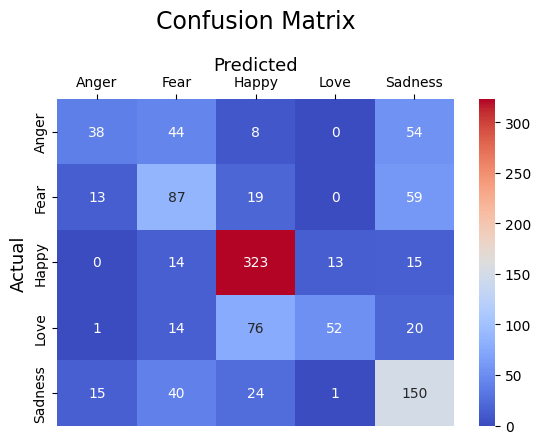



Klasifikasi Support Vector Machine dengan TF-IDF Vectorizer:

Confusion Matrix
[[ 43  40   4   0  57]
 [ 15  77  17   2  67]
 [  3  15 316  12  19]
 [  7   5  78  65   8]
 [ 11  45  18   0 156]]


Accuracy: 60.83333333333333
Precision: 60.56202001906868
Recall: 53.47965362263507
F1-Score: 54.472072422090356


              precision    recall  f1-score   support

           0       0.54      0.30      0.39       144
           1       0.42      0.43      0.43       178
           2       0.73      0.87      0.79       365
           3       0.82      0.40      0.54       163
           4       0.51      0.68      0.58       230

    accuracy                           0.61      1080
   macro avg       0.61      0.53      0.54      1080
weighted avg       0.62      0.61      0.59      1080



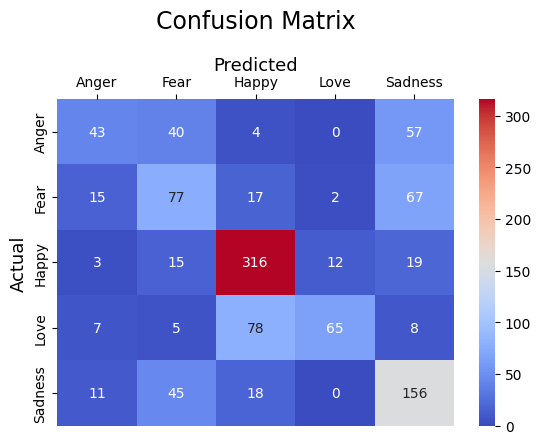



Klasifikasi Support Vector Machine dengan Hashing Vectorizer:

Confusion Matrix
[[ 43  48   7   0  46]
 [ 15  88  20   2  53]
 [  1  15 320  11  18]
 [  2   8  79  59  15]
 [ 13  49  22   1 145]]


Accuracy: 60.64814814814815
Precision: 61.00257200994059
Recall: 53.24206870285779
F1-Score: 54.193078891984094


              precision    recall  f1-score   support

           0       0.58      0.30      0.39       144
           1       0.42      0.49      0.46       178
           2       0.71      0.88      0.79       365
           3       0.81      0.36      0.50       163
           4       0.52      0.63      0.57       230

    accuracy                           0.61      1080
   macro avg       0.61      0.53      0.54      1080
weighted avg       0.62      0.61      0.59      1080



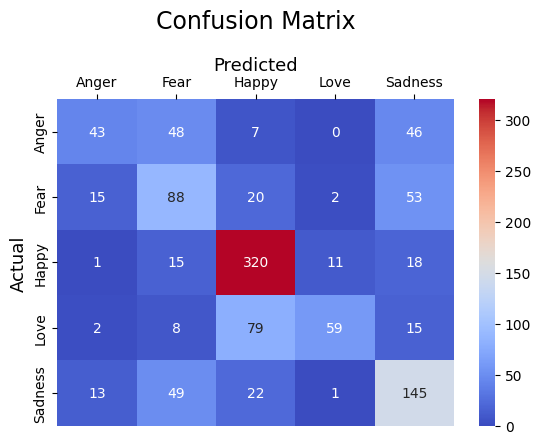



Klasifikasi Logistic Regression dengan Count Vectorizer:

Confusion Matrix
[[ 64  37   8   0  35]
 [ 34  74  24   5  41]
 [  4  14 303  32  12]
 [  0   3  64  81  15]
 [ 33  37  24   2 134]]


Accuracy: 60.74074074074074
Precision: 57.585436463567355
Recall: 55.39705957628126
F1-Score: 56.11235482021185


              precision    recall  f1-score   support

           0       0.47      0.44      0.46       144
           1       0.45      0.42      0.43       178
           2       0.72      0.83      0.77       365
           3       0.68      0.50      0.57       163
           4       0.57      0.58      0.57       230

    accuracy                           0.61      1080
   macro avg       0.58      0.55      0.56      1080
weighted avg       0.60      0.61      0.60      1080



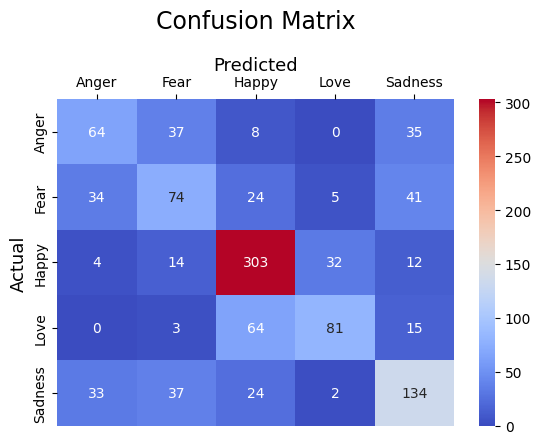



Klasifikasi Logistic Regression dengan TF-IDF Vectorizer:

Confusion Matrix
[[ 51  43  10   0  40]
 [ 17  88  20   4  49]
 [  2  14 311  17  21]
 [  0   4  77  69  13]
 [ 18  39  24   1 148]]


Accuracy: 61.75925925925926
Precision: 61.11235379854134
Recall: 55.34789255928546
F1-Score: 56.508216504776634


              precision    recall  f1-score   support

           0       0.58      0.35      0.44       144
           1       0.47      0.49      0.48       178
           2       0.70      0.85      0.77       365
           3       0.76      0.42      0.54       163
           4       0.55      0.64      0.59       230

    accuracy                           0.62      1080
   macro avg       0.61      0.55      0.57      1080
weighted avg       0.62      0.62      0.61      1080



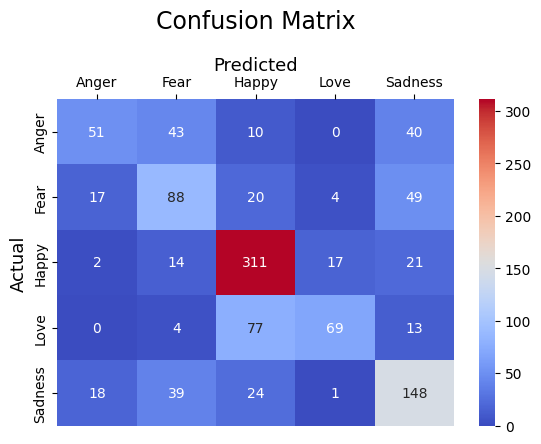



Klasifikasi Logistic Regression dengan Hashing Vectorizer:

Confusion Matrix
[[ 53  41  11   0  39]
 [ 19  85  22   4  48]
 [  3  13 317  17  15]
 [  0   5  79  64  15]
 [ 20  42  30   1 137]]


Accuracy: 60.74074074074074
Precision: 59.78143835369172
Recall: 54.04734013701973
F1-Score: 55.20274028983047


              precision    recall  f1-score   support

           0       0.56      0.37      0.44       144
           1       0.46      0.48      0.47       178
           2       0.69      0.87      0.77       365
           3       0.74      0.39      0.51       163
           4       0.54      0.60      0.57       230

    accuracy                           0.61      1080
   macro avg       0.60      0.54      0.55      1080
weighted avg       0.61      0.61      0.59      1080



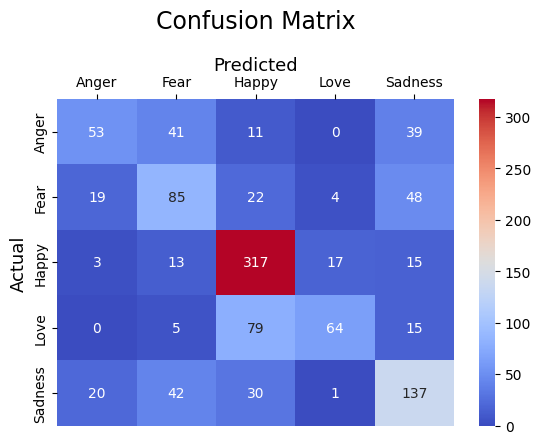



Klasifikasi Decision Tree dengan Count Vectorizer:

Confusion Matrix
[[ 64  35  11   3  31]
 [ 31  63  33  10  41]
 [ 15  17 263  49  21]
 [ 15   7  63  72   6]
 [ 35  39  22   8 126]]


Accuracy: 54.44444444444444
Precision: 50.58529937388305
Recall: 50.16937704574303
F1-Score: 50.271188668790835


              precision    recall  f1-score   support

           0       0.40      0.44      0.42       144
           1       0.39      0.35      0.37       178
           2       0.67      0.72      0.69       365
           3       0.51      0.44      0.47       163
           4       0.56      0.55      0.55       230

    accuracy                           0.54      1080
   macro avg       0.51      0.50      0.50      1080
weighted avg       0.54      0.54      0.54      1080



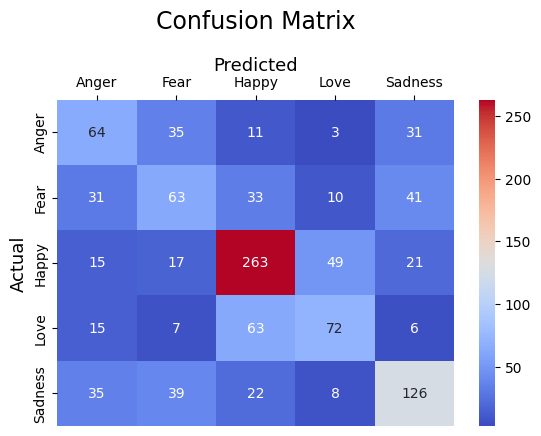



Klasifikasi Decision Tree dengan TF-IDF Vectorizer:

Confusion Matrix
[[ 61  40   4   2  37]
 [ 39  73  22   8  36]
 [  9  22 265  54  15]
 [ 15  10  63  68   7]
 [ 36  43  32   5 114]]


Accuracy: 53.7962962962963
Precision: 49.95762560335602
Recall: 49.4516191189084
F1-Score: 49.572882249764376


              precision    recall  f1-score   support

           0       0.38      0.42      0.40       144
           1       0.39      0.41      0.40       178
           2       0.69      0.73      0.71       365
           3       0.50      0.42      0.45       163
           4       0.55      0.50      0.52       230

    accuracy                           0.54      1080
   macro avg       0.50      0.49      0.50      1080
weighted avg       0.54      0.54      0.54      1080



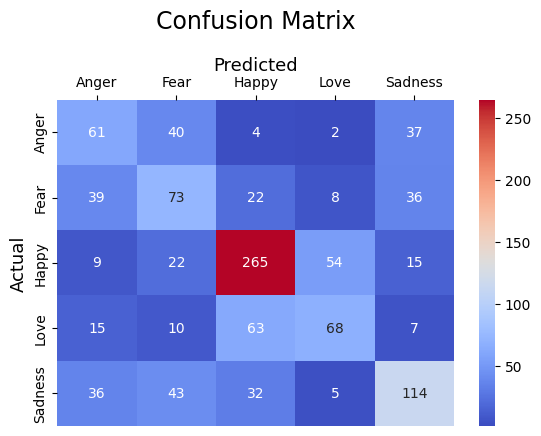



Klasifikasi Decision Tree dengan Hashing Vectorizer:

Confusion Matrix
[[ 59  34   9   4  38]
 [ 38  61  25   4  50]
 [ 13  19 265  44  24]
 [ 16   5  55  74  13]
 [ 42  37  21   4 126]]


Accuracy: 54.166666666666664
Precision: 50.40211169972125
Recall: 49.60520131427701
F1-Score: 49.77437566665255


              precision    recall  f1-score   support

           0       0.35      0.41      0.38       144
           1       0.39      0.34      0.37       178
           2       0.71      0.73      0.72       365
           3       0.57      0.45      0.51       163
           4       0.50      0.55      0.52       230

    accuracy                           0.54      1080
   macro avg       0.50      0.50      0.50      1080
weighted avg       0.54      0.54      0.54      1080



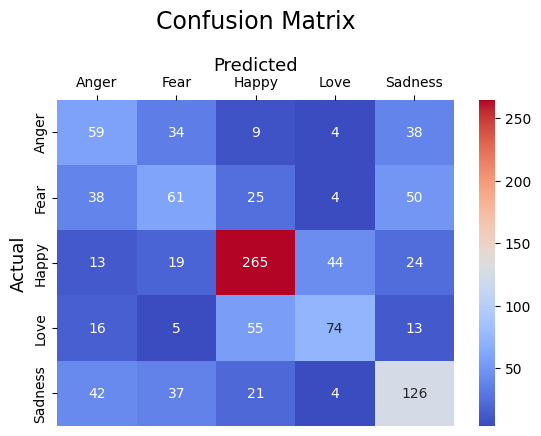



Klasifikasi K-Nearest Neighbor dengan Count Vectorizer:

Confusion Matrix
[[ 62  20  20  12  30]
 [ 44  28  62   6  38]
 [ 17   5 316  11  16]
 [ 23   2 108  22   8]
 [ 50  16  52   7 105]]


Accuracy: 49.351851851851855
Precision: 43.78612480416792
Recall: 40.9020683056683
F1-Score: 39.30455018073445


              precision    recall  f1-score   support

           0       0.32      0.43      0.36       144
           1       0.39      0.16      0.22       178
           2       0.57      0.87      0.68       365
           3       0.38      0.13      0.20       163
           4       0.53      0.46      0.49       230

    accuracy                           0.49      1080
   macro avg       0.44      0.41      0.39      1080
weighted avg       0.47      0.49      0.45      1080



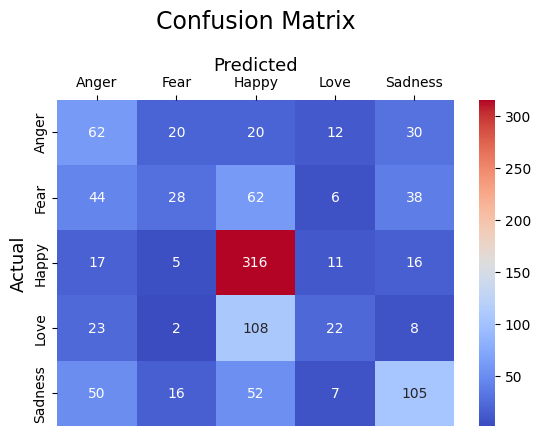



Klasifikasi K-Nearest Neighbor dengan TF-IDF Vectorizer:

Confusion Matrix
[[ 47  21  47   1  28]
 [ 26  42  71   3  36]
 [  1   4 350   7   3]
 [  1   1 132  28   1]
 [ 23  21  84   1 101]]


Accuracy: 52.59259259259259
Precision: 55.216619832433345
Recall: 42.643152610892166
F1-Score: 43.049328386588286


              precision    recall  f1-score   support

           0       0.48      0.33      0.39       144
           1       0.47      0.24      0.31       178
           2       0.51      0.96      0.67       365
           3       0.70      0.17      0.28       163
           4       0.60      0.44      0.51       230

    accuracy                           0.53      1080
   macro avg       0.55      0.43      0.43      1080
weighted avg       0.55      0.53      0.48      1080



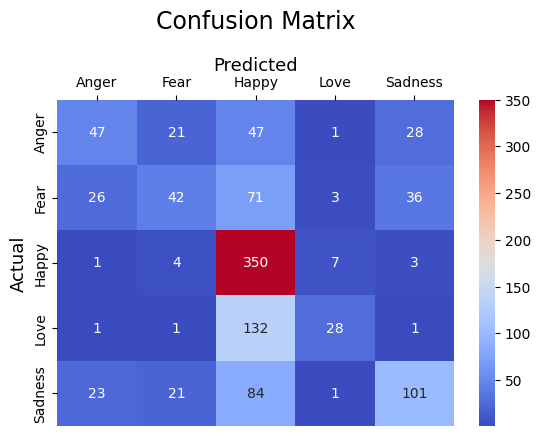



Klasifikasi K-Nearest Neighbor dengan Hashing Vectorizer:

Confusion Matrix
[[ 42  37  32   0  33]
 [ 21  49  79   1  28]
 [  2  10 342   8   3]
 [  2  11 122  24   4]
 [ 27  22  72   2 107]]


Accuracy: 52.22222222222223
Precision: 53.04779675044475
Recall: 42.32781044041927
F1-Score: 42.37736099457624


              precision    recall  f1-score   support

           0       0.45      0.29      0.35       144
           1       0.38      0.28      0.32       178
           2       0.53      0.94      0.68       365
           3       0.69      0.15      0.24       163
           4       0.61      0.47      0.53       230

    accuracy                           0.52      1080
   macro avg       0.53      0.42      0.42      1080
weighted avg       0.53      0.52      0.48      1080



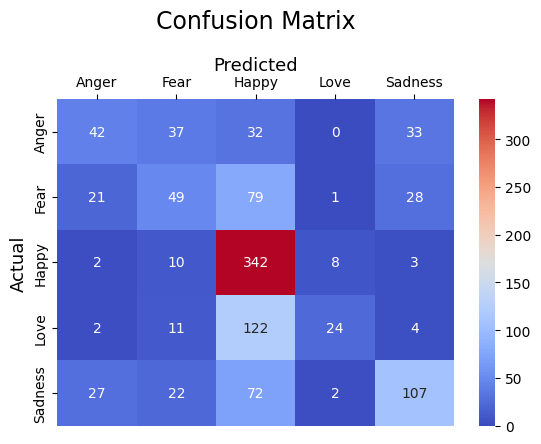

In [27]:
classification = [svm, lr, dt, knn]
clf_label = ['Support Vector Machine', 'Logistic Regression', 'Decision Tree', 'K-Nearest Neighbor']
vect = [co_vect, tf_vect, hash_vect]
vect_label = ['Count Vectorizer', 'TF-IDF Vectorizer', 'Hashing Vectorizer']

for i in range(len(classification)):
    for j in range(len(vect)):
        train = train_model(classification[i], vect[j], x_train, y_train)
        y_pred = train.predict(x_test)
        findMetrics(y_test, y_pred, clf_label[i], vect_label[j])



Klasifikasi Multinomial Naive Bayes dengan Count Vectorizer:

Confusion Matrix
[[ 37  42  14   1  50]
 [ 16  71  33   3  55]
 [  0   6 330  15  14]
 [  0   3 107  47   6]
 [  7  36  48   1 138]]


Accuracy: 57.68518518518518
Precision: 58.250837467294645
Recall: 48.96547992524262
F1-Score: 49.793669584083204


              precision    recall  f1-score   support

           0       0.62      0.26      0.36       144
           1       0.45      0.40      0.42       178
           2       0.62      0.90      0.74       365
           3       0.70      0.29      0.41       163
           4       0.52      0.60      0.56       230

    accuracy                           0.58      1080
   macro avg       0.58      0.49      0.50      1080
weighted avg       0.58      0.58      0.55      1080



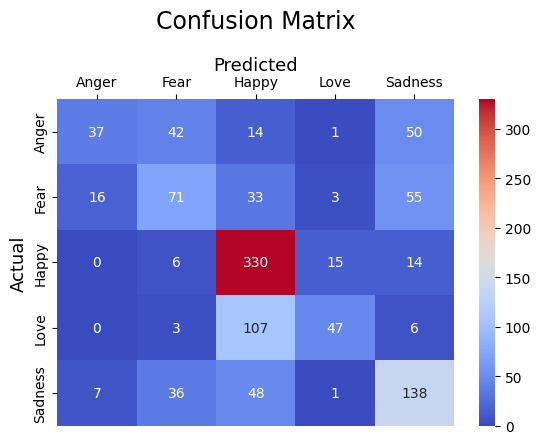



Klasifikasi Multinomial Naive Bayes dengan TF-IDF Vectorizer:

Confusion Matrix
[[ 16  26  33   0  69]
 [  1  35  62   0  80]
 [  0   1 353   1  10]
 [  0   0 147  12   4]
 [  0  15  70   0 145]]


Accuracy: 51.94444444444445
Precision: 66.40810273318014
Recall: 39.57836053552053
F1-Score: 36.682031094266286


              precision    recall  f1-score   support

           0       0.94      0.11      0.20       144
           1       0.45      0.20      0.27       178
           2       0.53      0.97      0.69       365
           3       0.92      0.07      0.14       163
           4       0.47      0.63      0.54       230

    accuracy                           0.52      1080
   macro avg       0.66      0.40      0.37      1080
weighted avg       0.62      0.52      0.44      1080



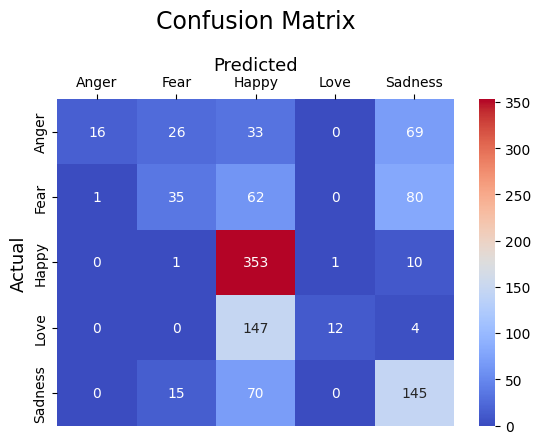



Klasifikasi Complement Naive Bayes dengan Count Vectorizer:

Confusion Matrix
[[ 52  46   9   7  30]
 [ 28  74  29   4  43]
 [  3   9 329  12  12]
 [  8   4  96  53   2]
 [ 19  40  46   2 123]]


Accuracy: 58.425925925925924
Precision: 56.240796501309575
Recall: 50.76294588264485
F1-Score: 51.65773172873096


              precision    recall  f1-score   support

           0       0.47      0.36      0.41       144
           1       0.43      0.42      0.42       178
           2       0.65      0.90      0.75       365
           3       0.68      0.33      0.44       163
           4       0.59      0.53      0.56       230

    accuracy                           0.58      1080
   macro avg       0.56      0.51      0.52      1080
weighted avg       0.58      0.58      0.56      1080



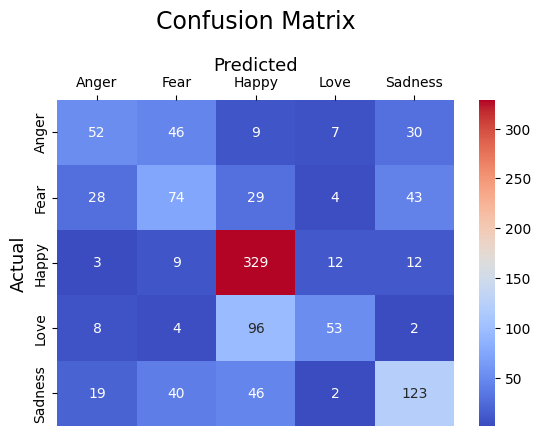



Klasifikasi Complement Naive Bayes dengan TF-IDF Vectorizer:

Confusion Matrix
[[ 53  39  10   5  37]
 [ 36  60  33   4  45]
 [  4   9 325  11  16]
 [  7   4  98  52   2]
 [ 16  39  45   3 127]]


Accuracy: 57.12962962962963
Precision: 54.861201437247416
Recall: 49.33474968193024
F1-Score: 50.14433116910935


              precision    recall  f1-score   support

           0       0.46      0.37      0.41       144
           1       0.40      0.34      0.36       178
           2       0.64      0.89      0.74       365
           3       0.69      0.32      0.44       163
           4       0.56      0.55      0.56       230

    accuracy                           0.57      1080
   macro avg       0.55      0.49      0.50      1080
weighted avg       0.57      0.57      0.55      1080



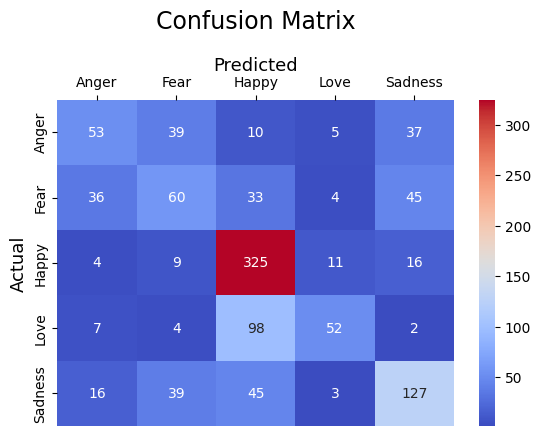



Klasifikasi Bernoulli Naive Bayes dengan Count Vectorizer:

Confusion Matrix
[[ 12  22  37   0  73]
 [  1  35  61   0  81]
 [  0   4 345   5  11]
 [  0   0 148  12   3]
 [  0  16  71   0 143]]


Accuracy: 50.64814814814815
Precision: 61.28919681544629
Recall: 38.41053577210315
F1-Score: 35.22439624054095


              precision    recall  f1-score   support

           0       0.92      0.08      0.15       144
           1       0.45      0.20      0.27       178
           2       0.52      0.95      0.67       365
           3       0.71      0.07      0.13       163
           4       0.46      0.62      0.53       230

    accuracy                           0.51      1080
   macro avg       0.61      0.38      0.35      1080
weighted avg       0.58      0.51      0.43      1080



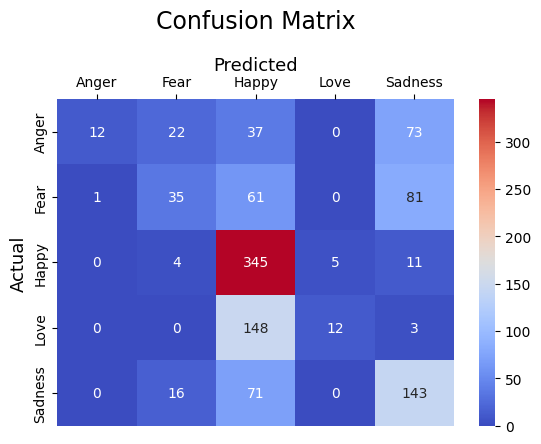



Klasifikasi Bernoulli Naive Bayes dengan TF-IDF Vectorizer:

Confusion Matrix
[[ 12  22  37   0  73]
 [  1  35  61   0  81]
 [  0   4 345   5  11]
 [  0   0 148  12   3]
 [  0  16  71   0 143]]


Accuracy: 50.64814814814815
Precision: 61.28919681544629
Recall: 38.41053577210315
F1-Score: 35.22439624054095


              precision    recall  f1-score   support

           0       0.92      0.08      0.15       144
           1       0.45      0.20      0.27       178
           2       0.52      0.95      0.67       365
           3       0.71      0.07      0.13       163
           4       0.46      0.62      0.53       230

    accuracy                           0.51      1080
   macro avg       0.61      0.38      0.35      1080
weighted avg       0.58      0.51      0.43      1080



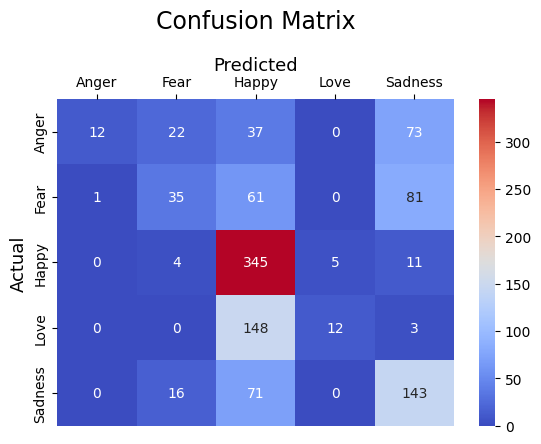

In [28]:
mnb = MultinomialNB()
cnb = ComplementNB()
bnb = BernoulliNB()

modelNB = [mnb, cnb, bnb]
modelNB_label = ['Multinomial Naive Bayes', 'Complement Naive Bayes', 'Bernoulli Naive Bayes']

vectNB = [co_vect, tf_vect]
vectNB_label = ['Count Vectorizer', 'TF-IDF Vectorizer']

for i in range(len(modelNB)):
    for j in range(len(vectNB)):
        train = train_model(modelNB[i], vectNB[j], x_train, y_train)
        y_pred = train.predict(x_test)
        findMetrics(y_test, y_pred, modelNB_label[i], vectNB_label[j])

In [ ]:
# berdasarkan hasil evaluasi di atas, akurasi tertinggi hanya logistic regression dengan TF-IDF
model_lr_tf = Pipeline([('vectorizer',tf_vect),('classifier',lr)])
model_lr_tf.fit(x_train,y_train)